In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import math
from sklearn.linear_model import LogisticRegression
def score_dataset(X, y, model = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [2]:
rain_file_path = 'data/train2_1.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [3]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [4]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1
...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [5]:
rain_data["year"] = (rain_data.index + 1) / 365
rain_data["year"] = np.ceil(rain_data.year)
rain_data = rain_data.astype({'year': 'int64'})

In [6]:
rain_data.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
rainfall           int64
year               int64
dtype: object

In [7]:
rain_data.year = rain_data.year.replace(8, 7)

<Axes: xlabel='year', ylabel='mintemp'>

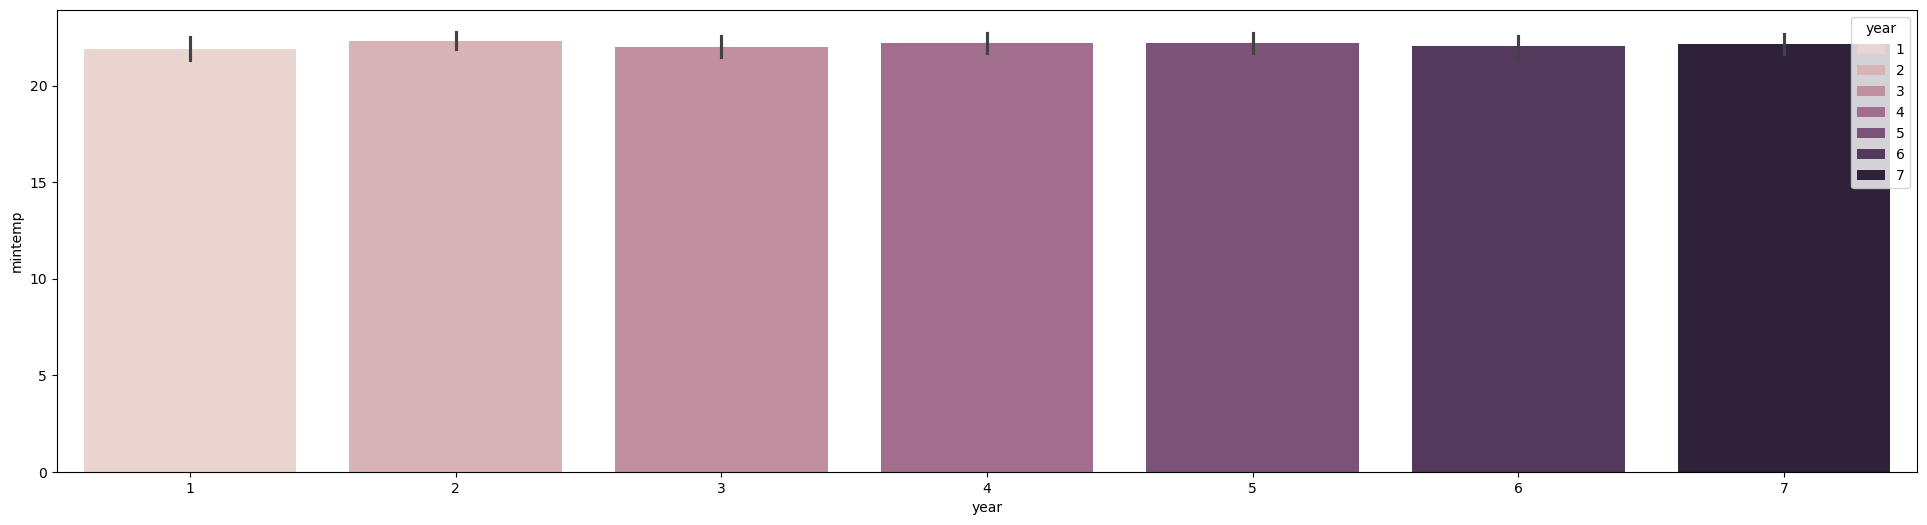

In [8]:
plt.figure(figsize=(24,6))
sns.barplot(y=rain_data.mintemp, x=rain_data.year, hue=rain_data.year)

In [9]:
for a in range(1,8):
    b = rain_data.loc[(rain_data.year == a ) & (rain_data.rainfall == 1)]
    print(b.shape)

(249, 12)
(265, 12)
(275, 12)
(272, 12)
(274, 12)
(276, 12)
(288, 12)


In [10]:
test_data["year"] = (test_data.index + 1) / 365
test_data["year"] = np.ceil(test_data.year)
test_data["year"] = test_data["year"] + 7
test_data = test_data.astype({'year': 'int64'})

In [11]:
rain_data["time"] = np.arange(len(rain_data.index))

In [12]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554


In [13]:
test_data["time"] = np.arange(len(test_data.index)) + 2556

In [14]:
test_data

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,8,2556
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,8,2557
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,8,2558
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,8,2559
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,8,2560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,9,3281
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,9,3282
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,9,3283
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,9,3284


In [15]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.232838
sunshine         0.161076
humidity         0.130928
time             0.084347
dewpoint         0.033111
temparature      0.028568
maxtemp          0.026417
mintemp          0.012622
pressure         0.011168
year             0.008852
windspeed        0.004863
winddirection    0.000524
Name: MI Scores, dtype: float64

In [16]:
rain_data['Lag_1'] = rain_data['rainfall'].shift(1)
rain_data.dropna(inplace=True, ignore_index=True)
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time,Lag_1
0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1,1.0
1,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2,1.0
2,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3,1.0
3,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4,1.0
4,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,14.5,1,1,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551,1.0
2551,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552,1.0
2552,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553,1.0
2553,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554,1.0


In [17]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
X_test = test_data
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.223735
sunshine         0.171171
humidity         0.144695
time             0.079328
dewpoint         0.034495
temparature      0.032664
mintemp          0.025211
pressure         0.019750
Lag_1            0.019555
maxtemp          0.019153
winddirection    0.012898
year             0.005488
windspeed        0.001694
Name: MI Scores, dtype: float64

In [18]:
cols = ["cloud", "sunshine", "humidity", "time"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity,time
0,83.0,0.6,81.0,1
1,91.0,0.0,95.0,2
2,88.0,1.0,90.0,3
3,81.0,0.0,95.0,4
4,51.0,7.7,84.0,5
...,...,...,...,...
2550,88.0,0.1,97.0,2551
2551,88.0,0.0,91.0,2552
2552,79.0,5.0,79.0,2553
2553,93.0,0.1,92.0,2554


In [19]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity,time
0,0.83,0.049587,0.725806,0.000000
1,0.91,0.000000,0.951613,0.000392
2,0.88,0.082645,0.870968,0.000783
3,0.81,0.000000,0.951613,0.001175
4,0.51,0.636364,0.774194,0.001566
...,...,...,...,...
2550,0.88,0.008264,0.983871,0.998434
2551,0.88,0.000000,0.887097,0.998825
2552,0.79,0.413223,0.693548,0.999217
2553,0.93,0.008264,0.903226,0.999608


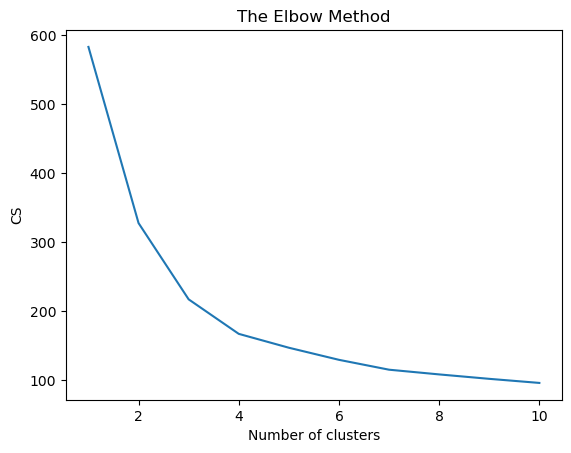

In [20]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 2008 out of 2555 samples were correctly labeled.
Accuracy score: 0.79


In [22]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 399 out of 2555 samples were correctly labeled.
Accuracy score: 0.16


In [23]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [24]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [25]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)
X["cluster"] = X_scaled["cluster"]
X_test["cluster"] = X_test_scaled["cluster"]

In [26]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time,Lag_1,Centroid_0,Centroid_1,Centroid_2,cluster
0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1.0,1.325358,2.145194,0.270599,2
1,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,2,1.0,1.403813,2.154932,0.329429,2
2,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,3,1.0,1.339001,2.145057,0.267432,2
3,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,4,1.0,1.380068,2.153982,0.326261,2
4,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,14.5,1,5,1.0,0.494595,1.391521,1.198029,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,7,2551,1.0,1.420976,0.340257,2.148029,0
2551,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,7,2552,1.0,1.404633,0.297288,2.142069,0
2552,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,7,2553,1.0,1.200103,0.366352,2.157651,0
2553,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,7,2554,1.0,1.416937,0.309818,2.143900,0


In [27]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.239789
Centroid_1       0.174929
Centroid_2       0.173654
sunshine         0.161835
Centroid_0       0.156949
humidity         0.148786
cluster          0.125533
time             0.079419
temparature      0.058328
maxtemp          0.030538
year             0.019695
dewpoint         0.014154
pressure         0.011560
winddirection    0.005876
Lag_1            0.000936
windspeed        0.000000
mintemp          0.000000
Name: MI Scores, dtype: float64

In [28]:
score_dataset(X, y)

0.8924339992745887


In [29]:
X = X.drop(labels = ("mintemp"), axis=1)
X_test = X_test.drop(labels = ("mintemp"), axis=1)
score_dataset(X, y)

0.892024455055671


In [30]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

0.8922077744940132


In [31]:
X_test

,id,day,pressure,maxtemp,temparature,dewpoint,humidity,cloud,sunshine,winddirection,year,time,Centroid_0,Centroid_1,Centroid_2,cluster
0,2190,1,1019.5,17.5,15.8,14.9,96.0,99.0,0.0,50.0,8,2556,1.325358,2.145194,0.270599,2
1,2191,2,1016.5,17.5,16.5,15.1,97.0,99.0,0.0,50.0,8,2557,1.403813,2.154932,0.329429,2
2,2192,3,1023.9,11.2,10.4,8.9,86.0,96.0,0.0,40.0,8,2558,1.339001,2.145057,0.267432,2
3,2193,4,1022.9,20.6,17.3,9.5,75.0,45.0,7.1,20.0,8,2559,1.380068,2.153982,0.326261,2
4,2194,5,1022.2,16.1,13.8,4.3,68.0,49.0,9.2,20.0,8,2560,0.494595,1.391521,1.198029,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,13.7,96.0,95.0,0.0,20.0,9,3281,1.320057,2.067525,0.184899,2
726,2916,362,1011.7,23.2,18.1,16.0,78.0,80.0,1.6,40.0,9,3282,1.347918,2.072603,0.232180,2
727,2917,363,1022.7,21.0,18.5,15.5,92.0,96.0,0.0,50.0,9,3283,1.317158,2.066731,0.178105,2
728,2918,364,1014.4,21.0,20.0,19.8,94.0,93.0,0.0,50.0,9,3284,1.316454,2.070899,0.230098,2


In [32]:
features = ["cloud", "cluster", "Centroid_1", "Centroid_0", "humidity", "sunshine", "Centroid_2", "temparature", "time", "humidity"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud       -0.450812 -0.000963  0.079824 -0.325011 -0.068951 -0.800334   
cluster     -0.002736  0.516547 -0.002789 -0.036164  0.300278 -0.010202   
Centroid_1   0.043799  0.516539  0.003056  0.006994  0.233848  0.063838   
Centroid_0  -0.449063 -0.014354  0.231051 -0.330898 -0.003653  0.524421   
humidity    -0.418999  0.011807 -0.442325  0.354723  0.016377  0.049214   
sunshine     0.461584 -0.006410 -0.260292  0.230803  0.037285 -0.236913   
Centroid_2   0.048319 -0.515218  0.008505  0.073855 -0.233769  0.075114   
temparature  0.160709 -0.020657 -0.693597 -0.685193 -0.053059  0.110229   
time        -0.029019 -0.447172 -0.004666 -0.060390  0.889376 -0.038795   
humidity    -0.418999  0.011807 -0.442325  0.354723  0.016377  0.049214   

                  PC7       PC8       PC9          PC10  
cloud        0.178887 -0.086450  0.000873 -1.602358e-16  
cluster     -0.002343  0.000092  0.800986  8.349560e-16  


In [33]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,dewpoint,humidity,cloud,sunshine,winddirection,year,time,...,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1022.0,21.7,18.9,15.6,81.0,83.0,0.6,50.0,1,1,...,-0.995085,2.676957,1.193638,-0.046406,-0.618964,0.226791,0.008715,-0.060928,0.031931,2.643389e-16
1,1019.7,20.3,19.3,18.4,95.0,91.0,0.0,40.0,1,2,...,-2.762258,2.680695,-0.252358,0.883373,-0.616795,0.201367,0.114614,-0.178622,0.059614,-5.400921e-17
2,1018.9,22.3,20.6,18.8,90.0,88.0,1.0,50.0,1,3,...,-1.949717,2.695655,-0.001850,0.440188,-0.611229,0.146645,0.154612,-0.075605,0.030927,-2.528323e-16
3,1015.9,21.3,20.7,19.9,95.0,81.0,0.0,40.0,1,4,...,-2.453798,2.676782,-0.491737,0.893607,-0.590657,0.629704,-0.035182,-0.148749,0.058036,-1.079616e-17
4,1018.8,24.3,20.9,18.0,84.0,51.0,7.7,20.0,1,5,...,1.307790,0.953406,-0.468241,1.720314,-1.292893,0.245216,0.043677,0.032868,-0.024635,9.853045e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.9,97.0,88.0,0.1,40.0,7,2551,...,-2.943668,-2.523163,-0.646542,0.968121,0.645572,0.312252,0.033817,-0.200762,-0.060471,-7.874261e-17
2551,1012.4,17.2,17.3,15.3,91.0,88.0,0.0,50.0,7,2552,...,-2.428176,-2.552156,0.433230,0.881448,0.643863,0.153590,0.013896,-0.136530,-0.041612,4.270790e-17
2552,1013.3,19.0,16.3,12.6,79.0,79.0,5.0,40.0,7,2553,...,-0.167012,-2.549160,1.359586,0.600964,0.708919,-0.190180,0.675823,0.056713,-0.072113,3.544003e-17
2553,1022.3,16.4,15.2,14.7,92.0,93.0,0.1,40.0,7,2554,...,-2.714691,-2.535972,0.621865,1.150426,0.657049,-0.082824,0.136114,-0.145754,-0.047823,-2.629623e-17


In [34]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [35]:
score_dataset(X, y)

0.8926096816879374


In [36]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.219210
PC1              0.199385
Centroid_1       0.174929
Centroid_2       0.173654
sunshine         0.172158
Centroid_0       0.156949
cluster          0.145164
PC2              0.139601
humidity         0.138053
time             0.080857
PC6              0.070638
PC5              0.058766
PC4              0.040122
PC8              0.036881
temparature      0.033474
maxtemp          0.031984
PC7              0.031861
dewpoint         0.031500
PC9              0.023628
PC3              0.022111
year             0.019850
Lag_1            0.013122
pressure         0.011527
winddirection    0.004857
PC10             0.000000
Name: MI Scores, dtype: float64

In [37]:
X = X.drop(labels = ("PC10"), axis=1)
X_test = X_test.drop(labels = ("PC10"), axis=1)
score_dataset(X, y)

0.8926096816879374


In [38]:
X = X.drop(labels = ("Lag_1"), axis=1)
#X_test = X_test.drop(labels = ("Lag_1"), axis=1)
score_dataset(X, y)

0.8918469602382249


In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.893056315622753


In [40]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/sit

-----
Best parameters {'C': 1.0, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.893
-----
CPU times: user 11.9 s, sys: 80.5 ms, total: 11.9 s
Wall time: 12.4 s


In [41]:
model_logistic_regression = LogisticRegression(C=1, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

In [42]:
X_test.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'year', 'time',
       'Centroid_0', 'Centroid_1', 'Centroid_2', 'cluster', 'PC1', 'PC2',
       'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'],
      dtype='object')

In [43]:
X.columns

Index(['pressure', 'maxtemp', 'temparature', 'dewpoint', 'humidity', 'cloud',
       'sunshine', 'winddirection', 'year', 'time', 'Centroid_0', 'Centroid_1',
       'Centroid_2', 'cluster', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6',
       'PC7', 'PC8', 'PC9'],
      dtype='object')

In [44]:
X_test = X_test.drop(labels = ("id"), axis=1)


In [45]:
X_test = X_test.drop(labels = ("day"), axis=1)


In [46]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

In [47]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('SubmissionTimeSeriesTimeLag.csv', columns=['id','rainfall'], index=False)